## Introduction
In this project we developed a content-based music recommendation system 
that suggests similar songs based on the similarity of their audio 
features and lyrical themes. The dataset used contains 28,372 songs with 
22 numerical features.

To measure similarity between songs, we used cosine similarity, since 
this metric is sensitive only to the direction (angle) of vectors rather 
than their absolute magnitude making it more suitable than Euclidean 
distance for comparing the relative pattern of features between songs.

### The formula to find the cosine similarity between two vectors is:
$$S_C(x, y) = \frac{x \cdot y}{||x|| \times ||y||}$$

#### Reference:
[scikit-learn: Cosine Similarity](https://scikit-learn.org/stable/modules/metrics.html#cosine-similarity)

## Table of Contents
- [Data Loading](#Data-Loading)
- [Feature Selection](#Feature-Selection)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [plot similarity distribution](#Plot-similarity-function)
- [Recommendation Function](#Recommendation-Function)
- [Experiments](#Experiments)
- [MinMaxScaler](#MinMaxScaler)
- [PCA](#PCA)
- [StandardScaler](#StandardScaler)
- [Conclusion](#Conclusion)

In [1]:
# setup
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## Data Loading
The dataset used, tcc_ceds_music.csv, is from Kaggle and includes 28,372 
songs released between 1950 and 2019. In addition to basic information 
(artist_name, title, genre, release_date), each song contains 16 columns 
of lyrical topic scores (such as dating, violence, romantic) and 6 
extracted audio features (such as danceability, energy, valence). The 
simultaneous presence of these two types of features content-based 
(lyrical) and audio-based was the primary reason for selecting this 
dataset to build a multidimensional similarity model.

In [2]:
data = pd.read_csv("tcc_ceds_music.csv")
data.head()

,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.380299,0.117175,0.357739,0.454119,0.997992,0.901822,0.339448,0.137110,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.331745,0.647540,0.954819,0.000002,0.325021,0.263240,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.002770,0.225422,0.456298,0.585288,0.840361,0.000000,0.351814,0.139112,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.225889,0.001548,0.686992,0.744404,0.083935,0.199393,0.775350,0.743736,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.068800,0.001350,0.291671,0.646489,0.975904,0.000246,0.597073,0.394375,romantic,1.0


## Feature Selection
To construct the feature vector of each song, only numerical columns 
that are meaningful in terms of content similarity were selected. The 
`lyrics` column (raw song text) was excluded because it is not directly 
usable for computing cosine similarity. Similarly, the `genre` and 
`topic` columns are categorical and were excluded, since they are 
already numerically represented through the topic scores (such as 
`dating`, `violence`, etc.). Finally, the `len` column (lyric length) 
was excluded as it has no meaningful relationship to a song's mood or 
style.

In [3]:
columns = [
    'dating', 'violence', 'world/life', 'night/time', 
    'shake the audience', 'family/gospel', 'romantic', 
    'communication', 'obscene', 'music', 'movement/places', 
    'light/visual perceptions', 'family/spiritual', 'like/girls', 
    'sadness', 'feelings', 
    'danceability', 'loudness', 'acousticness', 
    'instrumentalness', 'valence', 'energy',
]

In [4]:
features = data[columns].copy()
features.head()

,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,...,family/spiritual,like/girls,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy
0,0.000598,0.063746,0.000598,0.000598,0.000598,0.048857,0.017104,0.263751,0.000598,0.039288,...,0.000598,0.000598,0.380299,0.117175,0.357739,0.454119,0.997992,0.901822,0.339448,0.137110
1,0.035537,0.096777,0.443435,0.001284,0.001284,0.027007,0.001284,0.001284,0.001284,0.118034,...,0.051124,0.001284,0.001284,0.001284,0.331745,0.647540,0.954819,0.000002,0.325021,0.263240
2,0.002770,0.002770,0.002770,0.002770,0.002770,0.002770,0.158564,0.250668,0.002770,0.323794,...,0.002770,0.002770,0.002770,0.225422,0.456298,0.585288,0.840361,0.000000,0.351814,0.139112
3,0.048249,0.001548,0.001548,0.001548,0.021500,0.001548,0.411536,0.001548,0.001548,0.001548,...,0.001548,0.081132,0.225889,0.001548,0.686992,0.744404,0.083935,0.199393,0.775350,0.743736
4,0.001350,0.001350,0.417772,0.001350,0.001350,0.001350,0.463430,0.001350,0.001350,0.001350,...,0.029755,0.001350,0.068800,0.001350,0.291671,0.646489,0.975904,0.000246,0.597073,0.394375


## Exploratory Data Analysis
To examine the data distribution more closely, the features were 
divided into two separate groups: lyrical features (16 columns of 
topic scores) and audio features (6 columns). This separation allows 
for an independent comparison of the distribution pattern within each 
group in the plots that follow.

In [5]:
lyric_cols = [
    'dating', 'violence', 'world/life', 'night/time', 
    'shake the audience', 'family/gospel', 'romantic', 
    'communication', 'obscene', 'music', 'movement/places', 
    'light/visual perceptions', 'family/spiritual', 'like/girls', 
    'sadness', 'feelings'
]
audio_cols = ['danceability', 'loudness', 'acousticness', 'instrumentalness', 'valence', 'energy']

As shown in the plot, most lyrical topic columns (such as dating, 
shake the audience, family/gospel) have a highly concentrated 
distribution near zero, along with a large number of outliers at the 
upper end of the range. This shows that each song usually has a high 
score on one or two specific topics, rather than uniformly across all 
topics a phenomenon that makes this category of features sparse. 
This sparsity later became the main reason for the issues observed 
when computing cosine similarity during the analysis.

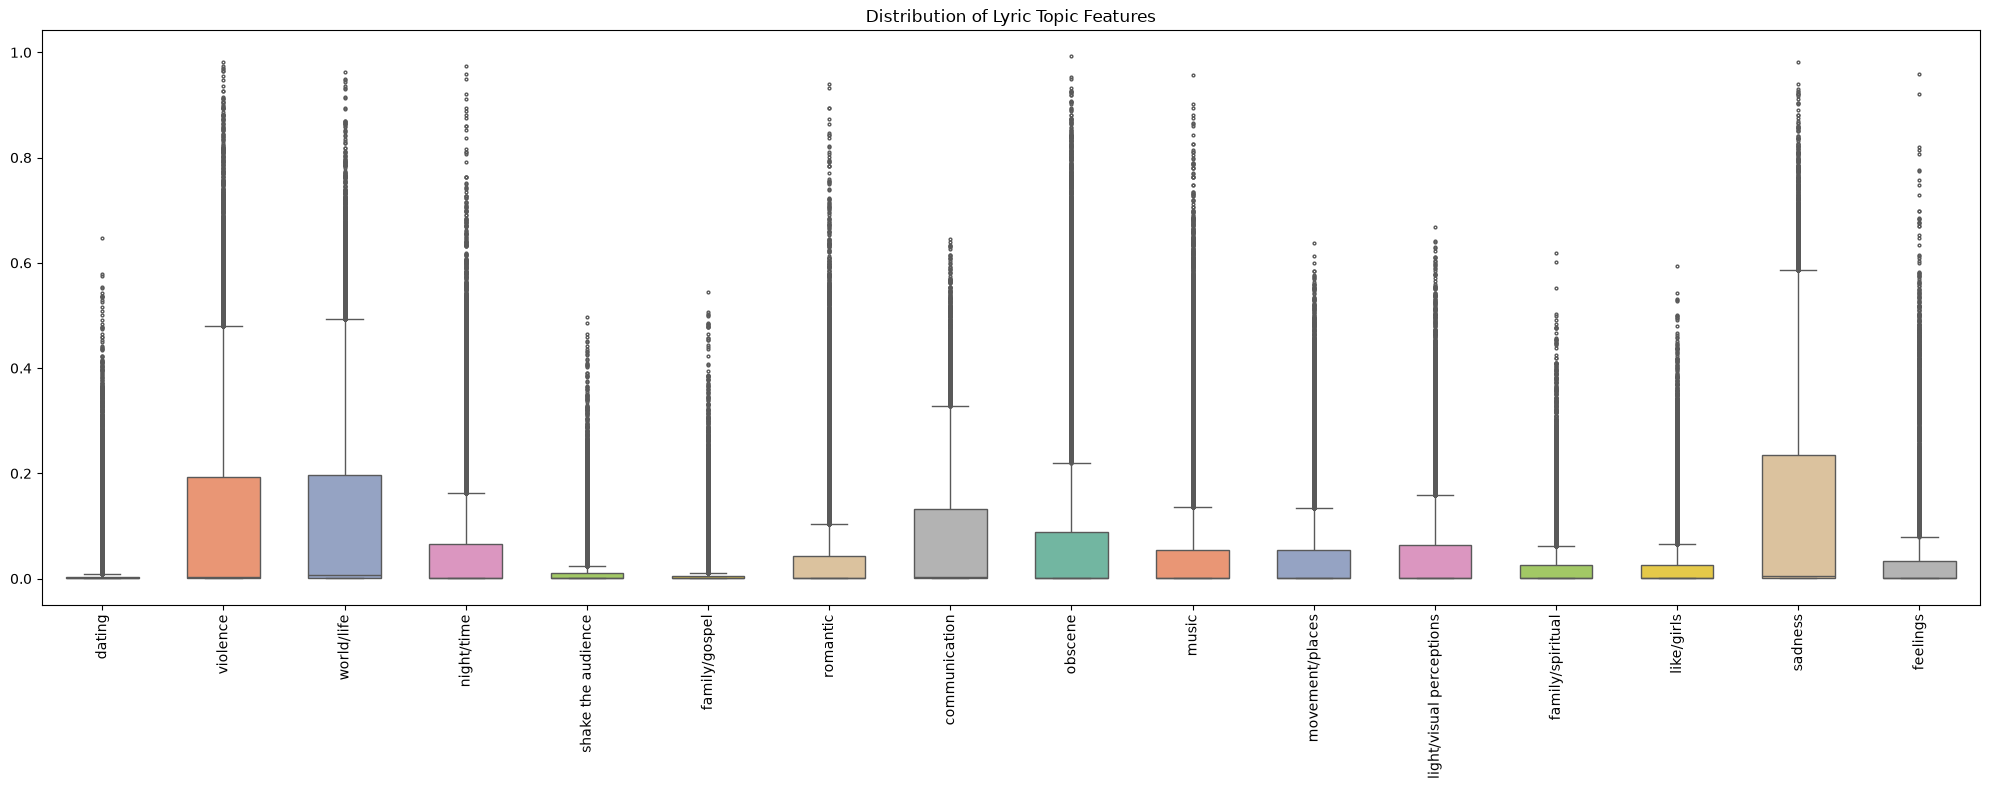

In [6]:
plt.figure(figsize=(20, 8))
sns.boxplot(features[lyric_cols], fliersize=2, linewidth=1, width=0.6, palette="Set2")
plt.xticks(rotation=90)
plt.title("Distribution of Lyric Topic Features")
plt.tight_layout()
plt.show()

Unlike the lyrical topic features, most audio features (particularly 
danceability, valence, energy, and acousticness) exhibit a more 
balanced and wider distribution within the 0 to 1 range, indicating 
that these features vary significantly across different songs. A 
notable exception is the instrumentalness column, which, similar to 
the lyrical features, has a concentrated distribution near zero. This 
is logical, as the majority of songs in this dataset contain vocals 
and are not purely instrumental.

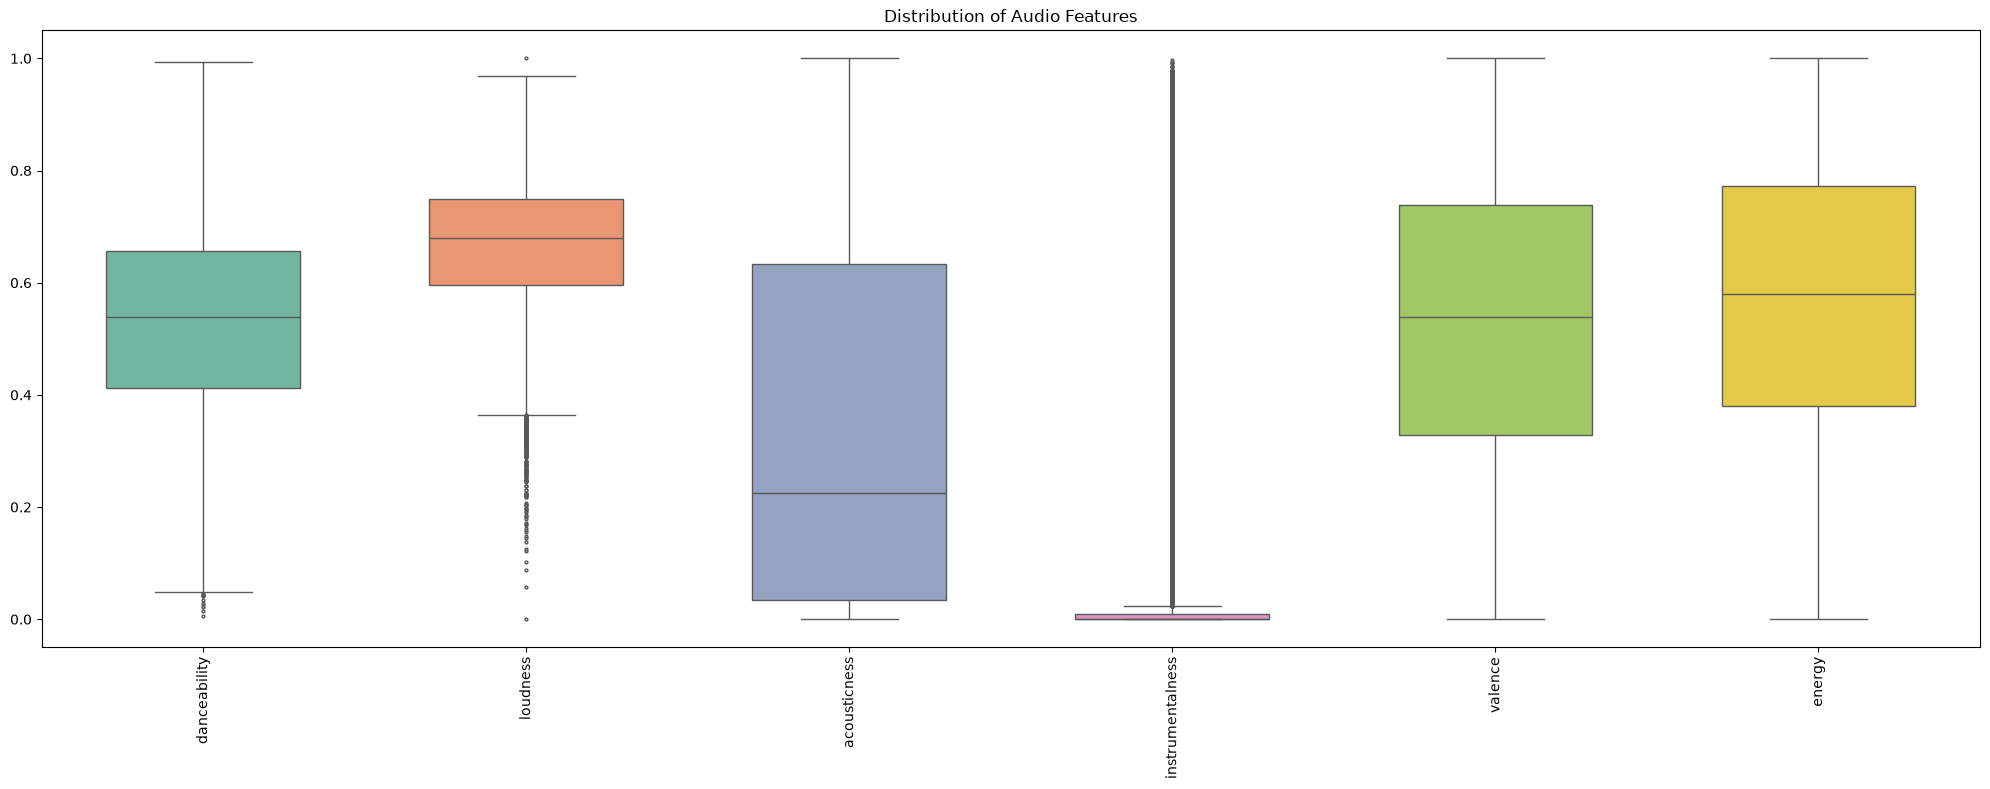

In [7]:
plt.figure(figsize=(20, 8))
sns.boxplot(features[audio_cols], fliersize=2, linewidth=1, width=0.6, palette="Set2")
plt.xticks(rotation=90)
plt.title("Distribution of Audio Features")
plt.tight_layout()
plt.show()

Examining the minimum and maximum values of each column reveals that all features have already been approximately normalized within the 0 to 1 range. However, the actual range of each column is not identical; for instance, the maximum value of the "shake the audience" column is only 0.497, whereas the "obscene" column reaches 0.992. This lack of uniformity indicates that the data was only approximately normalized, rather than precisely and uniformly. Consequently, the explicit application of a uniform scaler was necessary to ensure the exact comparability of all features.

In [8]:
features.describe().loc[["min", "max"]]

,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,...,family/spiritual,like/girls,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy
min,0.000291,0.000284,0.000291,0.000289,0.000284,0.000289,0.000284,0.000291,0.000289,0.000289,...,0.000284,0.000284,0.000284,0.000289,0.005415,0.0,2.811248e-07,0.000000,0.0,0.0
max,0.647706,0.981781,0.962105,0.973684,0.497463,0.545303,0.940789,0.645829,0.992298,0.956938,...,0.618073,0.594459,0.981424,0.958810,0.993502,1.0,1.000000e+00,0.996964,1.0,1.0


## Plot similarity function
This function plots the distribution of cosine similarity scores between a given song and every other song in the dataset used throughout this notebook to visually compare how well each normalization method separates similar from dissimilar songs.

In [9]:
def plot_similarity_distribution(data, features, title, color="#2F017D", sample_song="sweater weather", artist_name=None):
    sample_song = sample_song.lower()
    
    if artist_name:
        artist_name = artist_name.lower()
        mask = (data['track_name'] == sample_song) & (data['artist_name'] == artist_name)
    else:
        mask = data['track_name'] == sample_song
    mask = data[mask].index
    idx = mask[0]
    similarity = cosine_similarity(features[idx:idx+1], features)[0]
    similarity = np.delete(similarity, idx)
    
    plt.figure(figsize=(10, 6))
    plt.xlim(0, 1)
    plt.hist(similarity, bins=40, color=color)
    plt.title(title)
    plt.xlabel("Cosine similarity")
    plt.ylabel("Number of songs")
    
    plt.tight_layout()
    plt.show()

## Recommendation Function
The following function returns $N$ similar songs for a given input song based on cosine similarity. A key design consideration is that similarity is computed on-demand and exclusively for that single song (`features[idx:idx+1]` against the entire `features` array), rather than by precomputing a full $N \times N$ matrix. The rationale for this choice is memory constraints: for this dataset of 28,372 songs, constructing the complete similarity matrix would require approximately 6 gigabytes of memory, which is impractical on many systems. In contrast, on-demand computation generates only a $1 \times N$ vector, which has a negligible memory footprint and can be computed in a fraction of a second.

In [10]:
def get_recommendations(song_title, data, features, top_n=10, artist_name=None):
    """
    we may have two different songs with similar names from different artists
    if user gives the artist_name we will search a song by its track_name and its artist_name
    """

    song_title = song_title.lower()
    
    if artist_name:
        artist_name = artist_name.lower()
        mask = (data['track_name'] == song_title) & (data['artist_name'] == artist_name)
    else:
        mask = data['track_name'] == song_title

    idx = data[mask].index # take the index of the specific song 
    
    if len(idx) == 0: # if there's no song with this name
        print(f"Song not found: {song_title}")
        return

    if len(idx) > 1: # if there are more than one song with this name
        matches = data.loc[idx, ['track_name', 'artist_name', 'genre', 'release_date']]
        print(f"Multiple matches found for '{song_title}':")
        print(f"{matches.to_string(index=False)}\n")
        print(f"Note: Using '{data.loc[idx[0], 'artist_name']}'. Pass artist_name to disambiguate.\n")

    idx = idx[0]

    sim_scores = cosine_similarity(features[idx:idx+1], features)[0]
    sim_scores = list(enumerate(sim_scores))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True) # sort songs based on their similarity scores
    sim_scores = sim_scores[1:top_n+1] # we start from 1 because we want the song itself to be excluded

    song_indices = [i[0] for i in sim_scores] # take indices of the songs
    scores = [round(i[1], 3) for i in sim_scores] # take similarity of each song and round it to 3 digits

    recommendations = data.iloc[song_indices][['track_name', 'artist_name', 'genre']].copy() # for each similar song give this features to user
    recommendations['similarity'] = scores # add another feature called similarity 

    print(f"Recommendations for '{song_title}' by {data.loc[idx, 'artist_name']}:\n")
    
    recommendations = recommendations.reset_index(drop=True)
    recommendations.index = recommendations.index + 1 
    
    return recommendations

## Experiments
The results of the first experiment, conducted without applying any explicit scaler, indicate that similarity scores for sweater weather fall within a very narrow range (0.979 to 0.985). This compressed range signifies that the model is unable to meaningfully distinguish between "highly similar" and "moderately similar" songs—essentially assigning nearly identical scores to almost all of them. This observation served as the first indication of an underlying issue, which subsequently guided our analysis toward investigating and applying different normalization methods (MinMaxScaler, and ultimately, StandardScaler).

In [11]:
recommendations = get_recommendations("sweater weather", data, features)
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

Recommendations for 'sweater weather' by the neighbourhood:

            track_name                        artist_name    genre  similarity
1        ocean as well  nahko and medicine for the people   reggae       0.985
2          bun babylon                           capleton   reggae       0.984
3        mirror mirror                                m2m      pop       0.984
4          treacherous                       taylor swift      pop       0.984
5             migraine                  twenty one pilots     rock       0.983
6              breathe                       blu cantrell      pop       0.983
7       shoot him down                      alice francis     jazz       0.982
8                knees                         bebe rexha      pop       0.982
9          appel local                                 83  hip hop       0.982
10  rainbow in the sky                       ziggy marley   reggae       0.979


In [12]:
recommendations = get_recommendations("love you like a love song", data, features)
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

Recommendations for 'love you like a love song' by selena gomez & the scene:

             track_name                 artist_name    genre  similarity
1            basketball                 kurtis blow  hip hop       0.983
2        american music              violent femmes      pop       0.983
3       jah pretty face                     culture   reggae       0.980
4             superstar                  paul davis  country       0.978
5             your song                    rita ora      pop       0.975
6   u can't sing r song  michael franti & spearhead   reggae       0.975
7       into the mystic                  joe cocker    blues       0.974
8     put you in a song                 keith urban  country       0.973
9           summer days               a r i z o n a     rock       0.971
10             loddy lo              chubby checker      pop       0.971


In [13]:
recommendations = get_recommendations("shape of my heart", data, features)
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

Multiple matches found for 'shape of my heart':
       track_name     artist_name genre  release_date
shape of my heart backstreet boys   pop          2000
shape of my heart           sting  rock          1993

Note: Using 'backstreet boys'. Pass artist_name to disambiguate.

Recommendations for 'shape of my heart' by backstreet boys:

                    track_name      artist_name    genre  similarity
1   dancin' away with my heart  lady antebellum  country       0.993
2                         fall    justin bieber      pop       0.991
3                      compass  lady antebellum  country       0.988
4                  fool's gold    one direction      pop       0.987
5                       most i         chronixx   reggae       0.986
6                     i wonder      blind melon      pop       0.986
7              let it all show    the sheepdogs    blues       0.986
8                 heart attack      demi lovato      pop       0.985
9         keep you much longer           

The following plot confirms visually that, without any scaling, the model fails to meaningfully distinguish between songs nearly all similarity scores are compressed into the same narrow, high range.

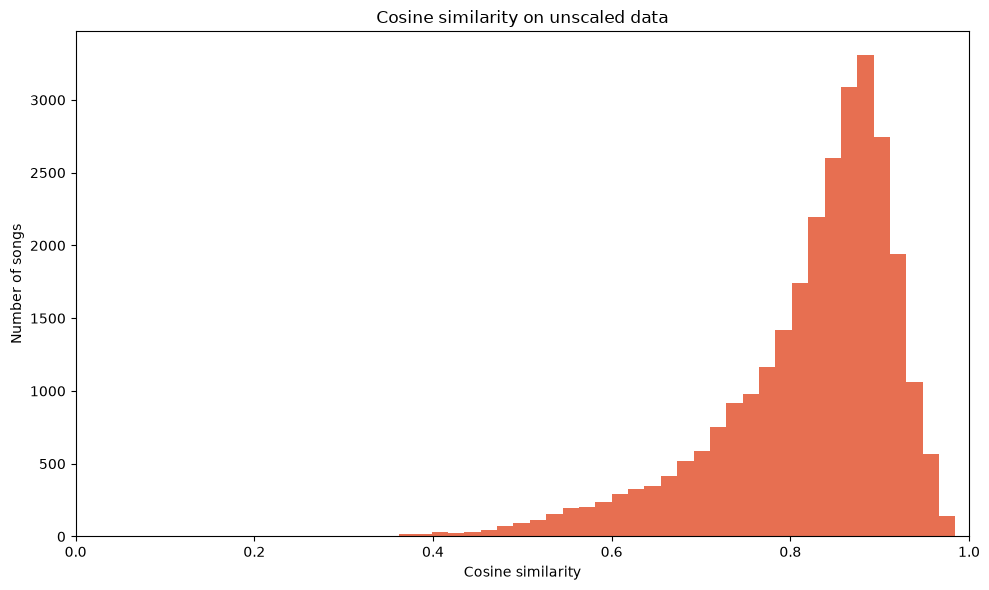

In [14]:
plot_similarity_distribution(data, features, "Cosine similarity on unscaled data", color="#e76f51")

## MinMaxScaler

In [15]:
scaler = MinMaxScaler()
features_MinMax_scaled = scaler.fit_transform(features)
features_MinMax_scaled = pd.DataFrame(features_MinMax_scaled, columns=columns)

In [16]:
recommendations = get_recommendations("sweater weather", data, features_MinMax_scaled)
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

Recommendations for 'sweater weather' by the neighbourhood:

                         track_name                        artist_name  \
1                       appel local                                 83   
2                           breathe                       blu cantrell   
3                       treacherous                       taylor swift   
4                     ocean as well  nahko and medicine for the people   
5                    shoot him down                      alice francis   
6                rainbow in the sky                       ziggy marley   
7                       bun babylon                           capleton   
8                           keep on                          the green   
9   survival a.k.a. black survivors           bob marley & the wailers   
10                    mirror mirror                                m2m   

      genre  similarity  
1   hip hop       0.979  
2       pop       0.979  
3       pop       0.978  
4    reggae       0.

In [17]:
recommendations = get_recommendations("love you like a love song", data, features_MinMax_scaled)
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

Recommendations for 'love you like a love song' by selena gomez & the scene:

                 track_name                       artist_name    genre  \
1            american music                    violent femmes      pop   
2           jah pretty face                           culture   reggae   
3                basketball                       kurtis blow  hip hop   
4         put you in a song                       keith urban  country   
5           into the mystic                        joe cocker    blues   
6                 superstar                        paul davis  country   
7       u can't sing r song        michael franti & spearhead   reggae   
8               black snake  black joe lewis & the honeybears    blues   
9   we are bulletproof pt.2                               bts      pop   
10              summer days                     a r i z o n a     rock   

    similarity  
1        0.979  
2        0.966  
3        0.965  
4        0.957  
5        0.953  
6    

As shown below, MinMax scaling did not resolve this issue the model still cannot meaningfully separate similar from dissimilar songs.

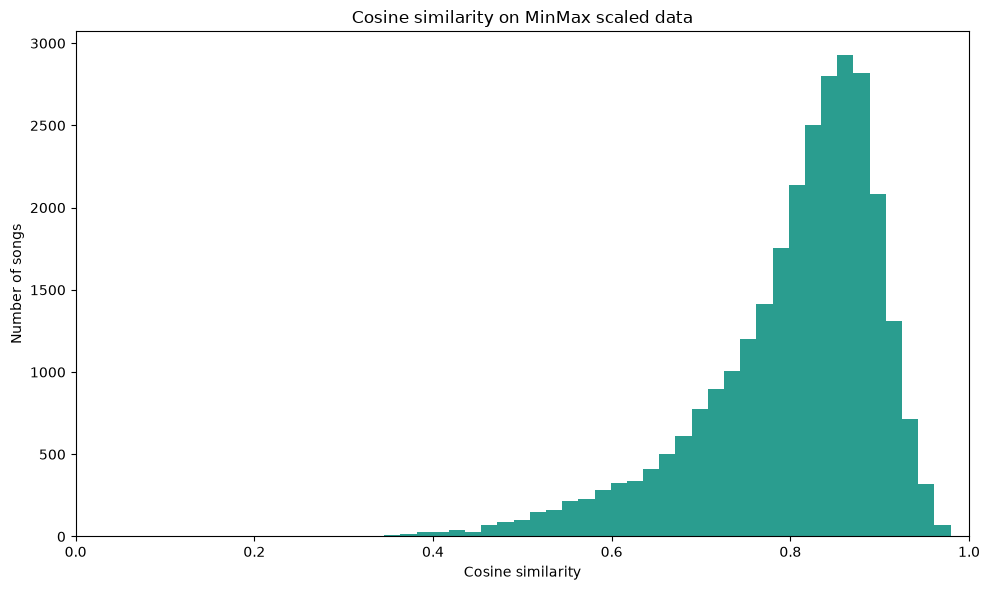

In [18]:
plot_similarity_distribution(data, features_MinMax_scaled, "Cosine similarity on MinMax scaled data", color="#2a9d8f")

## PCA
Due to insufficient improvement after MinMaxScaler and the high number 
of features (especially the 16 sparse lyric columns), PCA was applied 
for dimensionality reduction. The cumulative explained variance shows 
that 15 components preserve about 95% of the total variance.

(In hindsight, 22 features is not really "high-dimensional" the 
curse of dimensionality typically applies at a much larger scale. This 
was a reasonable first hypothesis, but the real cause turned out to be 
different, as the analysis below shows.)

In [19]:
pca = PCA()
pca.fit(features_MinMax_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

Text(0, 0.5, 'Cumulative Explained Variance')

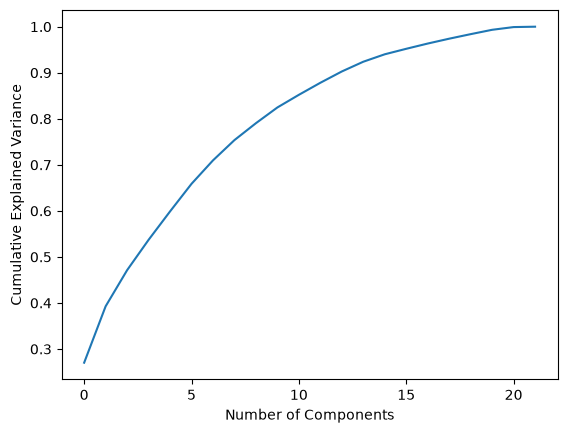

In [20]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

In [21]:
pca = PCA(n_components=15)
features_pca = pca.fit_transform(features_MinMax_scaled)

In [22]:
recommendations = get_recommendations("sweater weather", data, features_pca)
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

Recommendations for 'sweater weather' by the neighbourhood:

                     track_name        artist_name    genre  similarity
1                      headz up        nappy roots  hip hop       0.893
2                   bun babylon           capleton   reggae       0.887
3                      cover me     jo dee messina  country       0.882
4                   treacherous       taylor swift      pop       0.878
5   lemme see (feat. rick ross)              usher      pop       0.878
6             go to the mirror!            the who     rock       0.875
7               wake up america      darryl worley  country       0.867
8                    upper hand         rebelution   reggae       0.866
9            in the name of god       ziggy marley   reggae       0.866
10                     migraine  twenty one pilots     rock       0.866


In [23]:
recommendations = get_recommendations("love you like a love song", data, features_pca)
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

Recommendations for 'love you like a love song' by selena gomez & the scene:

                 track_name                 artist_name    genre  similarity
1                basketball                 kurtis blow  hip hop       0.972
2   we are bulletproof pt.2                         bts      pop       0.950
3           jah pretty face                     culture   reggae       0.942
4     created by the father              gregory isaacs   reggae       0.916
5               summer days               a r i z o n a     rock       0.899
6         put you in a song                 keith urban  country       0.885
7             feel the rush                      shaggy   reggae       0.880
8       u can't sing r song  michael franti & spearhead   reggae       0.875
9           into the mystic                  joe cocker    blues       0.872
10             mr. saxobeat              alexandra stan      pop       0.866


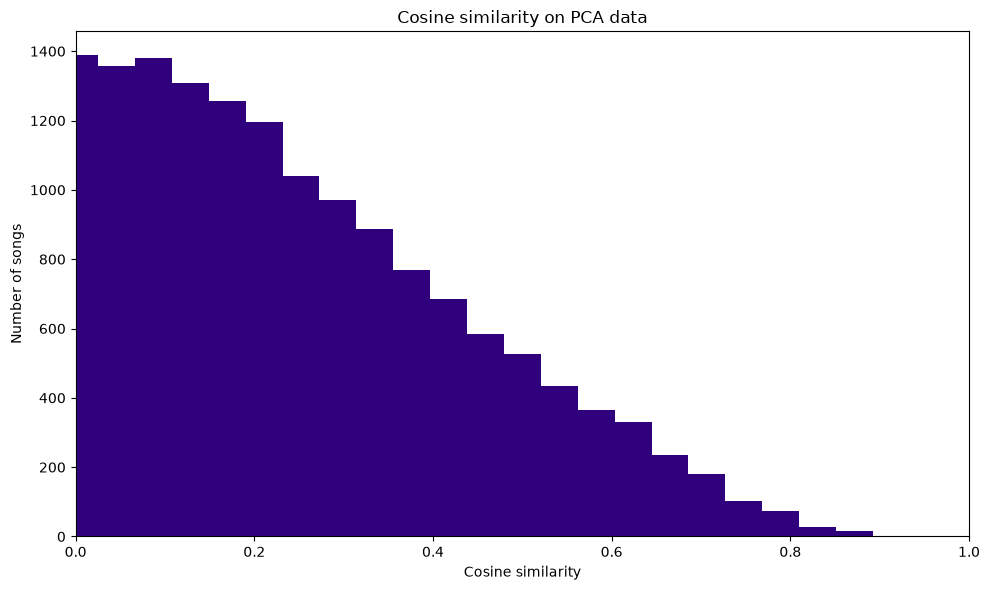

In [24]:
plot_similarity_distribution(data, features_pca, "Cosine similarity on PCA data")

In [25]:
loadings = pd.Series(pca.components_[0], index=columns).abs().sort_values(ascending=False)
print(loadings.head(10))

acousticness    0.757700
energy          0.532131
valence         0.240596
loudness        0.181906
obscene         0.115751
violence        0.103499
danceability    0.094523
sadness         0.076067
romantic        0.069502
music           0.058195
dtype: float64


In [26]:
# Fit PCA with ALL components (no reduction), so we can inspect any subset later
pca_full = PCA(n_components=22)
features_pca_full = pca_full.fit_transform(features_MinMax_scaled)

idx1 = data[(data['track_name'] == "love you like a love song") &
            (data['artist_name'] == "selena gomez & the scene")].index[0]
idx2 = data[(data['track_name'] == "basketball") &
            (data['artist_name'] == "kurtis blow")].index[0]

vec1_full = features_pca_full[idx1]
vec2_full = features_pca_full[idx2]

# similarity using only the first 15 components (what we actually used)
sim_kept = cosine_similarity(vec1_full[:15].reshape(1, -1), vec2_full[:15].reshape(1, -1))[0][0]

# similarity using only the last 7 components (the ones we discarded)
sim_discarded = cosine_similarity(vec1_full[15:].reshape(1, -1), vec2_full[15:].reshape(1, -1))[0][0]

print(f"Similarity using the 15 kept components:     {sim_kept:.3f}")
print(f"Similarity using the 7 discarded components:  {sim_discarded:.3f}")

Similarity using the 15 kept components:     0.972
Similarity using the 7 discarded components:  -0.174


Results after PCA did not improve for some song pairs, the score even 
increased to 0.972. However, unlike MinMaxScaler, this issue did not 
affect every pair uniformly: the distribution above shows that most 
scores remained relatively spread out, with only a few specific pairs 
receiving artificially high scores.

Inspecting the component loadings showed why: the first principal 
component (PC1) was dominated almost entirely by acousticness, 
energy, and valence, while the 16 lyrical-topic features contributed 
very little. This suggests PC1 behaves mainly as an audio axis rather 
than a balanced representation of all features.

To confirm this, we computed the cosine similarity between one of the 
high-scoring pairs twice: once using only the 15 retained components, 
and once using only the 7 discarded ones. Similarity on the discarded 
components was not just lower but negative (-0.174 vs. 0.972) 
indicating the discarded components didn't merely contribute less to 
the similarity, they actively pointed in opposite directions. This 
suggests the discarded components carried genuine discriminating 
signal, most likely related to lyrical content, that PCA dropped 
simply because it had low overall variance.

Because PCA selects components based solely on overall variance, it 
can silently discard exactly the information needed to distinguish a 
specific pair of songs, regardless of how important that dimension is 
for that pair. This finding led us to test StandardScaler on the full 
feature set, without any dimensionality reduction.

## StandardScaler
By using StandardScaler, the highest similarity score decreased
to 0.831, and the gap between the first and tenth ranks increased
significantly (compared to the near-zero gap in previous experiments).
This result confirms that centering the data around a mean of zero—rather than
dimensionality reduction or normalization to the 0–1 range—was the key factor in 
resolving the model's lack of differentiation.

In [27]:
scaler = StandardScaler()
features_Standard_scaled = scaler.fit_transform(features)
features_Standard_scaled = pd.DataFrame(features_Standard_scaled, columns=columns)

In [28]:
recommendations = get_recommendations("sweater weather", data, features_Standard_scaled)
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

Recommendations for 'sweater weather' by the neighbourhood:

         track_name            artist_name    genre  similarity
1    tabloid junkie        michael jackson      pop       0.800
2           keep on              the green   reggae       0.780
3           breathe           blu cantrell      pop       0.774
4   outrage! is now  death from above 1979    blues       0.770
5      skin & bones         eli young band  country       0.765
6              fear             ben rector     rock       0.765
7       appel local                     83  hip hop       0.764
8         fraccions                   soen     jazz       0.755
9          anointed                  bugle   reggae       0.744
10          warrant      foster the people     rock       0.743


In [29]:
recommendations = get_recommendations("love you like a love song", data, features_Standard_scaled)
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

Recommendations for 'love you like a love song' by selena gomez & the scene:

                  track_name      artist_name    genre  similarity
1                     hawaii   the beach boys      pop       0.888
2             american music   violent femmes      pop       0.838
3     if i ever get you back    morgan wallen  country       0.827
4                spring rain  the go-betweens      pop       0.824
5    i'm a fool for you girl           t. rex    blues       0.813
6                     studio      schoolboy q      pop       0.812
7   i like the sound of that    rascal flatts  country       0.812
8                  i'm yours        the green   reggae       0.811
9          edge of seventeen     stevie nicks     rock       0.809
10               man in love     eric clapton    blues       0.805


In [30]:
recommendations = get_recommendations("shape of my heart", data, features_Standard_scaled, artist_name="sting")
print(recommendations[["track_name", "artist_name", "genre", "similarity"]])

Recommendations for 'shape of my heart' by sting:

                            track_name        artist_name    genre  similarity
1                       1-800-273-8255              logic      pop       0.938
2                     thinkin bout you        frank ocean      pop       0.891
3           i can't even drink it away       charlie rich  country       0.882
4                             abuse me        silverchair      pop       0.869
5                          funny blues         art pepper     jazz       0.858
6     let's fall in love for the night            finneas      pop       0.847
7                        twilight zone       van morrison      pop       0.845
8   cut my lip (40.6782°n, 73.9442° w)  twenty one pilots     rock       0.844
9                     i killed hip hop              lil b  hip hop       0.841
10                             pitiful       big maybelle    blues       0.835


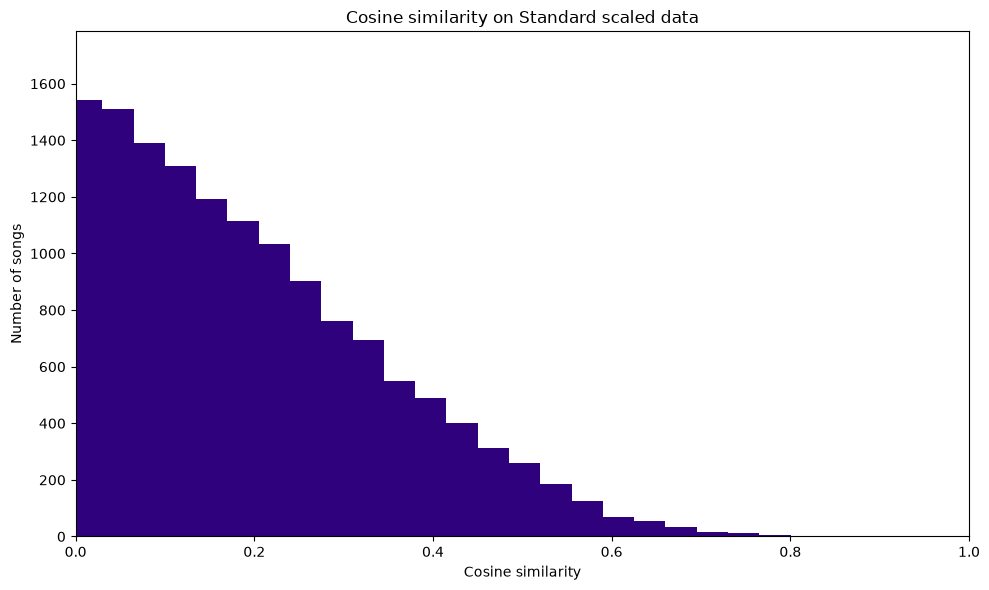

In [31]:
plot_similarity_distribution(data, features_Standard_scaled, "Cosine similarity on Standard scaled data")

Comparing the range of scores between the two experimental songs shows 
that "Sweater Weather" falls within 0.743–0.800, while "Love You Like 
a Love Song" falls within 0.805–0.888. Unlike the earlier experiments 
where the ranges were completely overlapping and inseparable these 
two ranges are now fully separated, with no overlap at all. This 
confirms the model can reliably distinguish between these two 
thematically different songs.

While the top-10 recommendations for sweater weather before scaling were compressed into a narrow band (0.979–0.985), the full distribution across all songs shows the deeper issue: most songs skewed toward high similarity regardless of actual content, making it hard to distinguish a great match from an okay match. After StandardScaler, the distribution shifts toward lower similarity for most songs, with only a smaller subset showing meaningfully elevated scores.

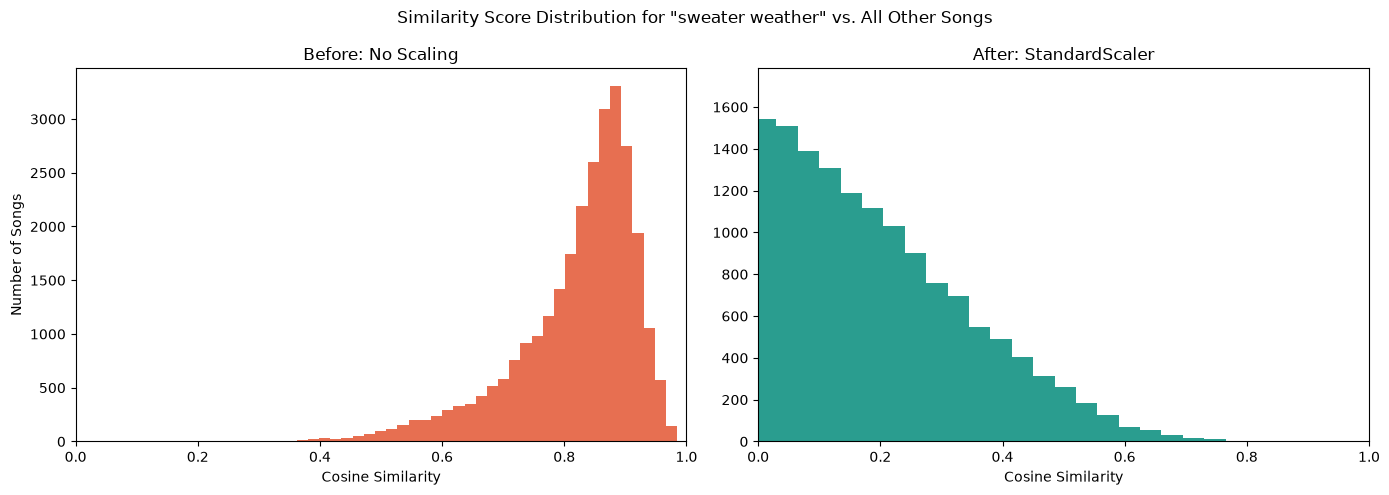

In [32]:
sample_song = "sweater weather"
idx = data[data['track_name'] == sample_song].index[0]

sim_before = cosine_similarity(features[idx:idx+1], features)[0]
sim_before = np.delete(sim_before, idx)  # excluding the song itself

sim_after = cosine_similarity(features_Standard_scaled[idx:idx+1], features_Standard_scaled)[0]
sim_after = np.delete(sim_after, idx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sim_before, bins=40, color="#e76f51")
axes[0].set_xlim(0, 1)
axes[0].set_title("Before: No Scaling")
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Number of Songs")

axes[1].hist(sim_after, bins=40, color="#2a9d8f")
axes[1].set_xlim(0, 1)
axes[1].set_title("After: StandardScaler")
axes[1].set_xlabel("Cosine Similarity")

plt.suptitle(f'Similarity Score Distribution for "{sample_song}" vs. All Other Songs')
plt.tight_layout()
plt.savefig("similarity_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## Conclusion
Finally, the model developed in this project is a content-based 
recommendation system that recommends similar songs based on the 
similarity between songs' audio features and lyrical topics, using 
cosine similarity and StandardScaler.

The most important finding of this project was that the type of data 
normalization (StandardScaler vs. MinMaxScaler) played a much more 
important role than dimensionality reduction (PCA) in improving the 
model's discriminative power. Closer examination revealed a more 
nuanced explanation for PCA's failure: by selecting components solely 
based on total variance, PCA could inadvertently discard important 
discriminating signal contained in certain low-variance components.

However, since `genre` was not included in the feature vector, 
recommendations can still cross genre boundaries. Applying separate 
weighting to audio and lyrical features, rather than treating all 22 
dimensions equally, could be a promising direction for the future 
development of this project.